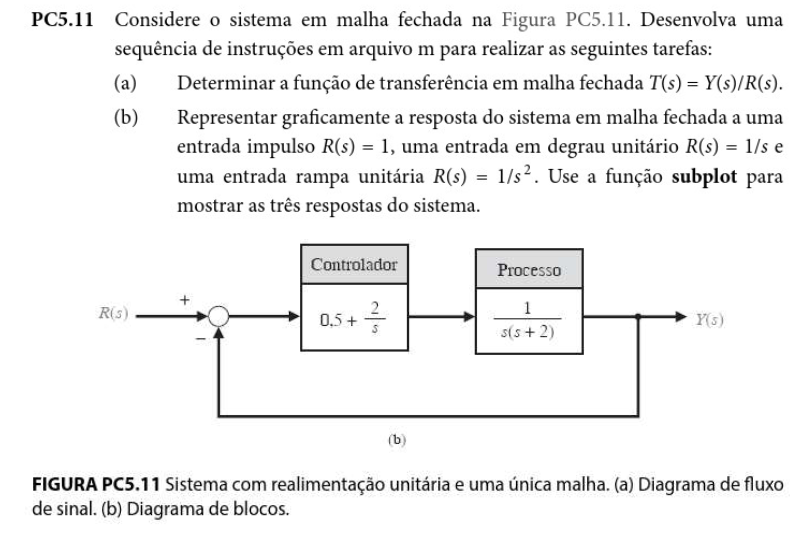

PARTE (a): FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA

Controlador G_c(s) = 0.5 + 2/s:
<TransferFunction>: sys[51]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.5 s + 2
  ---------
      s

Processo G_p(s) = 1/(s(s+2)):
<TransferFunction>: sys[56]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      1
  ---------
  s^2 + 2 s

Função de transferência em malha aberta G_ol(s) = G_c(s)*G_p(s):
<TransferFunction>: sys[57]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.5 s + 2
  -----------
  s^3 + 2 s^2

Função de transferência em malha fechada T(s) = Y(s)/R(s):
<TransferFunction>: sys[59]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         0.5 s + 2
  -----------------------
  s^3 + 2 s^2 + 0.5 s + 2

Numerador: 0.5s + 2.0
Denominador: s³ + 2.0s² + 0.5s + 2.0

PARTE (b): RESPOSTA A DIFERENTES ENTRADAS


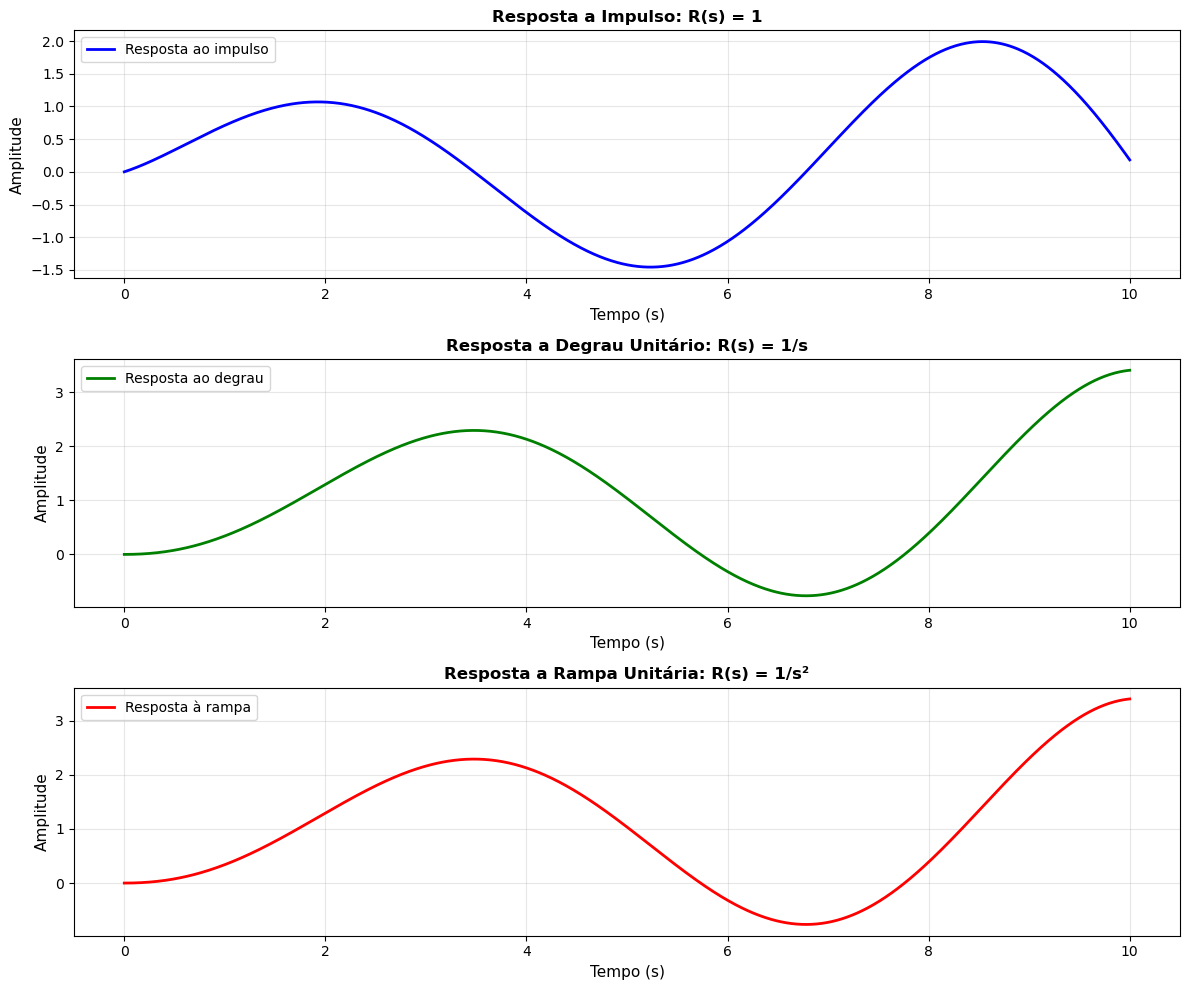


ANÁLISE DE ESTABILIDADE

Zeros do sistema:
  Zero 1: -4.000000

Polos do sistema em malha fechada:
  Polo 1: -2.188978
  Polo 2: 0.094489+0.951178j
  Polo 3: 0.094489-0.951178j

Sistema é estável? NÃO ✗


In [4]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

# Definir a variável de Laplace
s = ct.tf('s')

# (a) Determinar a função de transferência em malha fechada T(s) = Y(s)/R(s)

# Controlador: G_c(s) = 0.5 + 2/s
G_c = 0.5 + 2/s

# Processo: G_p(s) = 1/(s(s+2))
G_p = 1/(s*(s+2))

# Função de transferência em malha aberta
G_ol = G_c * G_p

# Função de transferência em malha fechada com realimentação unitária negativa
# T(s) = G_ol(s) / (1 + G_ol(s))
T = ct.feedback(G_ol)

print("=" * 60)
print("PARTE (a): FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA")
print("=" * 60)
print("\nControlador G_c(s) = 0.5 + 2/s:")
print(G_c)
print("\nProcesso G_p(s) = 1/(s(s+2)):")
print(G_p)
print("\nFunção de transferência em malha aberta G_ol(s) = G_c(s)*G_p(s):")
print(G_ol)
print("\nFunção de transferência em malha fechada T(s) = Y(s)/R(s):")
print(T)

# Obter numerador e denominador
num, den = ct.tfdata(T)
print("\nNumerador: {0:.1f}s + {1:.1f}".format(num[0][0][0], num[0][0][1]))
print("Denominador: s³ + {0:.1f}s² + {1:.1f}s + {2:.1f}".format(
    den[0][0][1], den[0][0][2], den[0][0][3]))

print("\n" + "=" * 60)
print("PARTE (b): RESPOSTA A DIFERENTES ENTRADAS")
print("=" * 60)

# Criar vetor de tempo
t = np.linspace(0, 10, 1000)

# Calcular respostas
# Resposta ao impulso
t_impulse, y_impulse = ct.impulse_response(T, t)

# Resposta ao degrau unitário
t_step, y_step = ct.step_response(T, t)

# Resposta à rampa unitária
# Rampa = degrau / s
T_ramp = T / s
t_ramp, y_ramp = ct.impulse_response(T_ramp, t)

# Criar figura com 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Resposta ao impulso R(s) = 1
axes[0].plot(t_impulse, y_impulse, 'b-', linewidth=2, label='Resposta ao impulso')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Tempo (s)', fontsize=11)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Resposta a Impulso: R(s) = 1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Resposta ao degrau unitário R(s) = 1/s
axes[1].plot(t_step, y_step, 'g-', linewidth=2, label='Resposta ao degrau')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Tempo (s)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Resposta a Degrau Unitário: R(s) = 1/s', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# Resposta à rampa unitária R(s) = 1/s²
axes[2].plot(t_ramp, y_ramp, 'r-', linewidth=2, label='Resposta à rampa')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Tempo (s)', fontsize=11)
axes[2].set_ylabel('Amplitude', fontsize=11)
axes[2].set_title('Resposta a Rampa Unitária: R(s) = 1/s²', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Análise de estabilidade - extrair polos e zeros das raízes do polinômio
print("\n" + "=" * 60)
print("ANÁLISE DE ESTABILIDADE")
print("=" * 60)

num_coeffs = num[0][0]
den_coeffs = den[0][0]

# Calcular zeros (raízes do numerador)
zeros = np.roots(num_coeffs)
print("\nZeros do sistema:")
for i, zero in enumerate(zeros):
    if np.isreal(zero):
        print(f"  Zero {i+1}: {np.real(zero):.6f}")
    else:
        print(f"  Zero {i+1}: {zero:.6f}")

# Calcular polos (raízes do denominador)
poles = np.roots(den_coeffs)
print("\nPolos do sistema em malha fechada:")
for i, pole in enumerate(poles):
    if np.isreal(pole):
        print(f"  Polo {i+1}: {np.real(pole):.6f}")
    else:
        print(f"  Polo {i+1}: {pole:.6f}")

# Verificar estabilidade
is_stable = np.all(np.real(poles) < 0)
print(f"\nSistema é estável? {'SIM ✓' if is_stable else 'NÃO ✗'}")
if is_stable:
    print("Todos os polos têm parte real negativa.")
